In [1]:
# FITS

In [5]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

image_data = []

for i in range(1, 6):
    filename = f"M13_000{i}.fits"
    
    with fits.open(filename) as hdul:
        image_data.append(hdul[0].data)
        
print(f"Successfully loaded {len(image_data)} images.")

Successfully loaded 5 images.


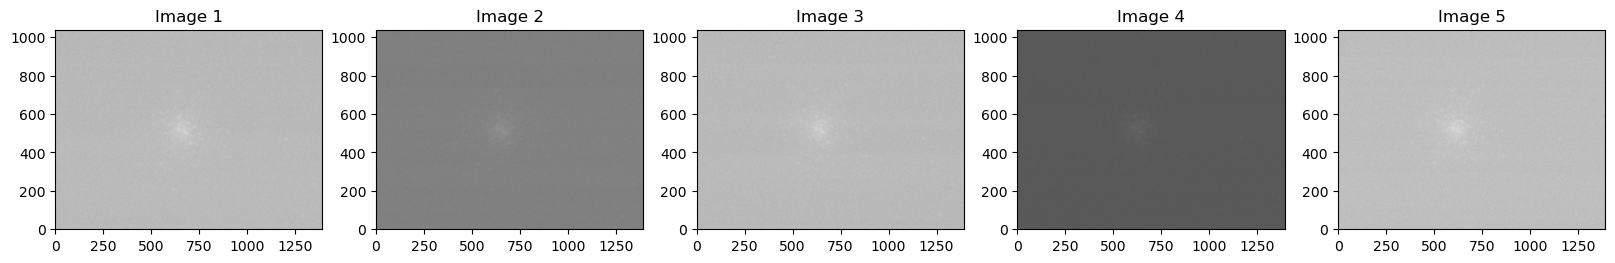

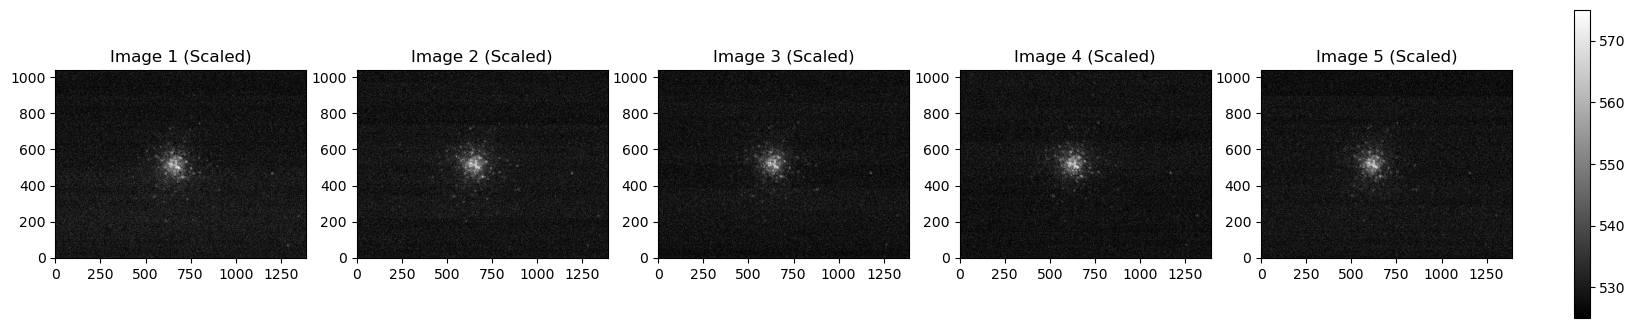

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    # Plot using origin="lower" as requested
    ax.imshow(image_data[i], origin='lower', cmap='gray')
    ax.set_title(f"Image {i+1}")
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in enumerate(axes):
    im = ax.imshow(image_data[i], origin='lower', cmap='gray', vmin=525, vmax=575)
    ax.set_title(f"Image {i+1} (Scaled)")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
plt.show()

# When scaled, the stars in each file are much more easily resolved; you can actually make out individual points of light

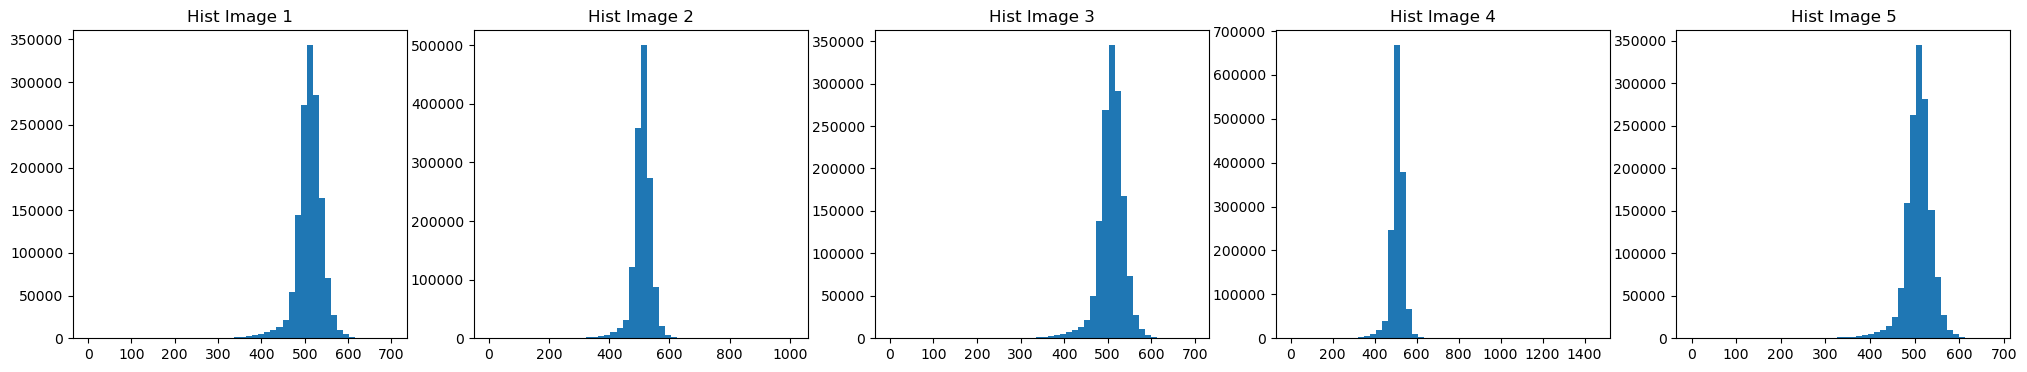

Image 1 -> Mean: 510.47, Median: 512.00
Image 2 -> Mean: 509.75, Median: 511.00
Image 3 -> Mean: 508.05, Median: 510.00
Image 4 -> Mean: 507.91, Median: 509.00
Image 5 -> Mean: 508.79, Median: 510.00


In [25]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for i, ax in enumerate(axes):
    ax.hist(image_data[i].ravel(), bins=50)
    ax.set_title(f"Hist Image {i+1}")
plt.show()

# Calculate statistics for question (e)
for i, data in enumerate(image_data):
    print(f"Image {i+1} -> Mean: {np.mean(data):.2f}, Median: {np.median(data):.2f}")

In [ ]:
# x-axis is Pixel Intensity, y-axis is Frequency
# range of pixel values is divided into 50 bins
# Most data is centered around 500 (representing the dark sky behind)
# The width represents background noise, the tail to the right represents stars
#     Spread ~ 400 - 600

In [28]:
stack_array = np.array(image_data)
combined_image = np.median(stack_array, axis=0)

print(f"Combined Image Median Value: {np.median(combined_image):.2f}")

Combined Image Median Value: 510.00


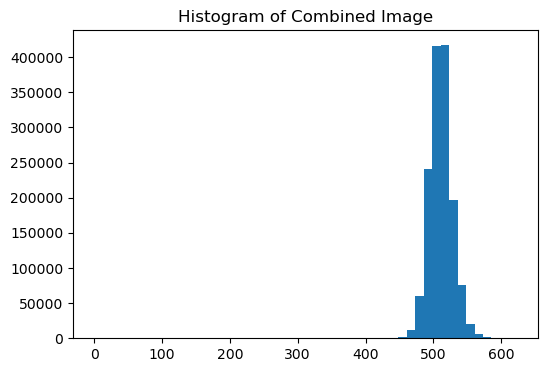

In [30]:
plt.figure(figsize=(6,4))
plt.hist(combined_image.ravel(), bins=50)
plt.title("Histogram of Combined Image")
plt.show()

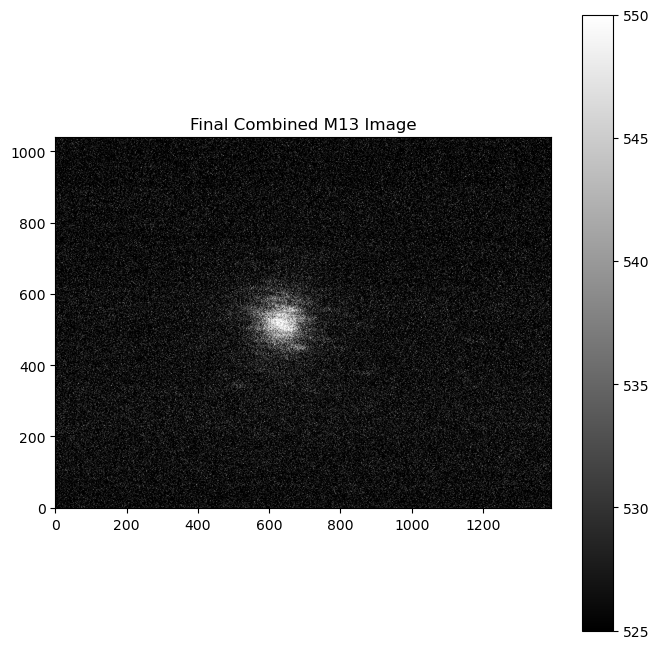

In [41]:
plt.figure(figsize=(8,8))
plt.imshow(combined_image, origin='lower', cmap='gray', vmin=525, vmax=550)
plt.title("Final Combined M13 Image")
plt.colorbar()
plt.show()

In [42]:
fits.writeto("combined.fits", combined_image, overwrite=True)
print("Saved combined.fits")

Saved combined.fits
